# Bitcoin vs S&P 500: is the Sharpe ratio difference real?

Over 2015–2026, Bitcoin's Sharpe ratio (1.02) is well above the S&P 500's (0.70). This notebook asks whether that gap is statistically distinguishable from chance once fat tails, correlation and instability over time are taken into account. Gold serves as a third, reference asset.

**Key findings**

- **The difference is not significant.** Bitcoin's lead of 0.32 Sharpe points has a standard error of about 0.34: p ≈ 0.35, 95% interval from −0.35 to 0.97 (paired block bootstrap and Jobson-Korkie-Memmel test agree).
- **The ranking depends on the start date.** Starting in January 2018, just after the 2017 peak, instead of January 2015 cuts Bitcoin's Sharpe ratio from 1.02 to 0.59 and moves it from first to last.
- **Detecting such a gap would take decades.** With a correlation of 0.24 between the two assets, about 57 years of daily data would be needed for a 0.32 gap to become significant at the 5% level.
- **Returns are far from normal.** A fitted Student t has 2.3 to 3.7 degrees of freedom, so theoretical kurtosis is infinite and sample kurtosis is unstable.
- **Correlations changed regime in 2020.** Bitcoin's correlation with equities rose from 0.02 to 0.39, and gold's moved from −0.17 to +0.15.

**Data**

| | |
|:---|:---|
| Assets | SPY (S&P 500 ETF, dividends reinvested), BTC-USD (Bitcoin), GLD (gold ETF) — Yahoo Finance via `yfinance`, adjusted closes |
| Risk-free rate | 3-month Treasury bill (FRED series `DTB3`), converted to a daily rate |
| Period | 2 January 2015 – 30 September 2026: 2,953 common trading days, 2,952 daily returns |
| Treatment | Only days when all three assets trade (US trading days); simple returns for Sharpe and Sortino ratios, log returns for volatility, correlation and distribution analysis |

**Tools:** Python, pandas, NumPy, SciPy, matplotlib, yfinance, fredapi, python-dotenv.

**Contents**

1. Data and returns
2. Volatility
3. Covariance and correlation
4. Sharpe and Sortino ratios
5. Normality
6. Student t distribution
7. Confidence intervals for Sharpe ratios
8. Testing the Sharpe ratio difference
9. Stability over time
10. Conclusion, limitations and references

## Setup

Imports, FRED API key (read from a `.env` file at the repository root) and global parameters.

In [1]:
import os

import numpy as np
import pandas as pd
import yfinance as yf
from dotenv import find_dotenv, load_dotenv
from fredapi import Fred
from scipy import stats

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, NullLocator, PercentFormatter
from matplotlib.transforms import blended_transform_factory

os.makedirs("assets", exist_ok=True)   # make sure the output folder exists

load_dotenv(find_dotenv(usecwd=True))   # FRED_API_KEY from the .env at the repo root

# --- parameters ---
TICKERS = {"SPY": "S&P 500", "BTC-USD": "Bitcoin", "GLD": "Gold"}
START = "2015-01-01"
END =  "2026-10-01"
TRADING_DAYS = 252

## 1. Data and returns

Adjusted closing prices are downloaded for the three assets. Only days when **all** assets trade are kept, *before* computing returns, so every return covers the same holding period across assets. Two return definitions are used:

- **simple returns** $R_t = P_t / P_{t-1} - 1$, for Sharpe and Sortino ratios: the arithmetic mean of simple returns is the expected return of a portfolio;
- **log returns** $r_t = \ln(P_t / P_{t-1})$, for volatility, correlation and distribution analysis.

The function raises an explicit error if a ticker comes back empty: `yfinance` does not fail on a bad ticker, and `dropna()` would otherwise silently delete every row.

In [2]:
def get_returns(tickers, start, end):
    """Download adjusted closes, keep common trading days, return simple and log returns."""
    try:
        prices = yf.download(list(tickers), start=start, end=end,
                             auto_adjust=True, progress=False)["Close"]
    except Exception as e:
        raise RuntimeError(f"Download failed for {list(tickers)}: {e}") from e

    # a failed ticker comes back as an all-NaN column (yfinance does not raise)
    missing = [t for t in tickers if t not in prices or prices[t].isna().all()]
    if missing:
        raise ValueError(f"No data for: {missing}")

    prices = prices[list(tickers)].rename(columns=tickers).dropna()  # common days BEFORE returns

    prices.columns.name = None   # remove the "Ticker" label left by yfinance

    returns = pd.concat({"simple": prices.pct_change(),
                         "log": np.log(prices).diff()}, axis=1).dropna()

    print(f"{len(prices)} common days | {prices.index[0].date()} to {prices.index[-1].date()}")

    return returns

In [3]:
returns = get_returns(TICKERS, START, END)
returns.head()

2953 common days | 2015-01-02 to 2026-09-30


simple                           log                    
             S&P 500   Bitcoin      Gold   S&P 500   Bitcoin      Gold
Date                                                                  
2015-01-05 -0.018059 -0.128743  0.015077 -0.018225 -0.137818  0.014965
2015-01-06 -0.009419  0.042682  0.011399 -0.009464  0.041796  0.011334
2015-01-07  0.012461  0.028471 -0.005891  0.012384  0.028073 -0.005909
2015-01-08  0.017745 -0.037331 -0.004209  0.017589 -0.038046 -0.004217
2015-01-09 -0.008013  0.024913  0.011385 -0.008046  0.024607  0.011321

In [4]:
print("Simple returns")
display(returns["simple"].describe().T)

print("Log returns")
display(returns["log"].describe().T)

Simple returns


,count,mean,std,min,25%,50%,75%,max
S&P 500,2952.0,0.000571,0.011045,-0.109424,-0.003708,0.000605,0.005926,0.105019
Bitcoin,2952.0,0.002753,0.041377,-0.371695,-0.015005,0.001631,0.019803,0.252472
Gold,2952.0,0.000461,0.010252,-0.102742,-0.004808,0.000567,0.005610,0.063587


Log returns


,count,mean,std,min,25%,50%,75%,max
S&P 500,2952.0,0.000510,0.011068,-0.115886,-0.003715,0.000605,0.005909,0.099863
Bitcoin,2952.0,0.001890,0.041592,-0.464730,-0.015118,0.001629,0.019610,0.225119
Gold,2952.0,0.000408,0.010276,-0.108412,-0.004820,0.000567,0.005594,0.061647


The sample has 2,953 common trading days (2,952 returns). For each asset, the mean log return is lower than the mean simple return by about σ²/2, as expected: 0.000061 per day for the S&P 500 (about 1.5% per year) but 0.000863 for Bitcoin (about 21.7% per year). This volatility drag matters for the Sharpe ratio comparison in section 4.

## 2. Volatility

Annualized volatility is the standard deviation of daily log returns times √252. A 50-day rolling window (past data only) shows how volatility changes over time; crisis periods are shaded (S&P 500 closing peak to closing trough).

In [5]:
# --- parameters ---
VOL_WINDOW = 50
CRISES = {                                   # S&P 500 closing peak -> closing trough
    "Covid crash": ("2020-02-19", "2020-03-23"),
    "2022 bear market": ("2022-01-03", "2022-10-12"),
    "2025 tariff shock": ("2025-02-19", "2025-04-08"),
}


def annualized_vol(log_returns, benchmark="S&P 500", periods=TRADING_DAYS):
    """Full-sample annualized volatility and ratio to a benchmark asset."""
    vol = log_returns.std() * np.sqrt(periods)
    return pd.DataFrame({"Annualized volatility": vol,
                         f"Ratio to {benchmark}": vol / vol[benchmark]})


def rolling_vol(log_returns, window=VOL_WINDOW, periods=TRADING_DAYS):
    """Trailing rolling annualized volatility (uses past data only: no look-ahead)."""
    return log_returns.rolling(window).std().dropna() * np.sqrt(periods)


def shade_crises(ax, crises=CRISES):
    """Grey out crisis periods and label them, centered, at the top of the chart."""
    label_pos = blended_transform_factory(ax.transData, ax.transAxes)
    for name, (start, end) in crises.items():
        start, end = pd.Timestamp(start), pd.Timestamp(end)
        ax.axvspan(start, end, color="grey", alpha=0.2)
        ax.text(start + (end - start) / 2, 0.97, name, transform=label_pos,
                fontsize=9, fontweight="bold", va="top", ha="center", color="dimgrey")


def plot_rolling_vol(vol, window=VOL_WINDOW, crises=CRISES):
    """Rolling volatility of each asset on a log scale, with crisis periods shaded."""
    fig, ax = plt.subplots(figsize=(12, 5))
    for col in vol:
        ax.plot(vol.index, vol[col], label=col, linewidth=1.2)
    shade_crises(ax, crises)

    ax.set_yscale("log")
    ax.yaxis.set_major_locator(FixedLocator([0.05, 0.10, 0.20, 0.50, 1.00, 2.00]))
    ax.yaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.set_ylabel(f"Annualized volatility ({window}-day rolling, log scale)")
    ax.set_title(f"{window}-day rolling volatility of daily log returns")
    ax.legend(loc="upper left", frameon=False)
    ax.grid(True, which="major", alpha=0.3)
    fig.tight_layout()
    return fig, ax

,Annualized volatility,Ratio to S&P 500
S&P 500,17.6%,1.00x
Bitcoin,66.0%,3.76x
Gold,16.3%,0.93x


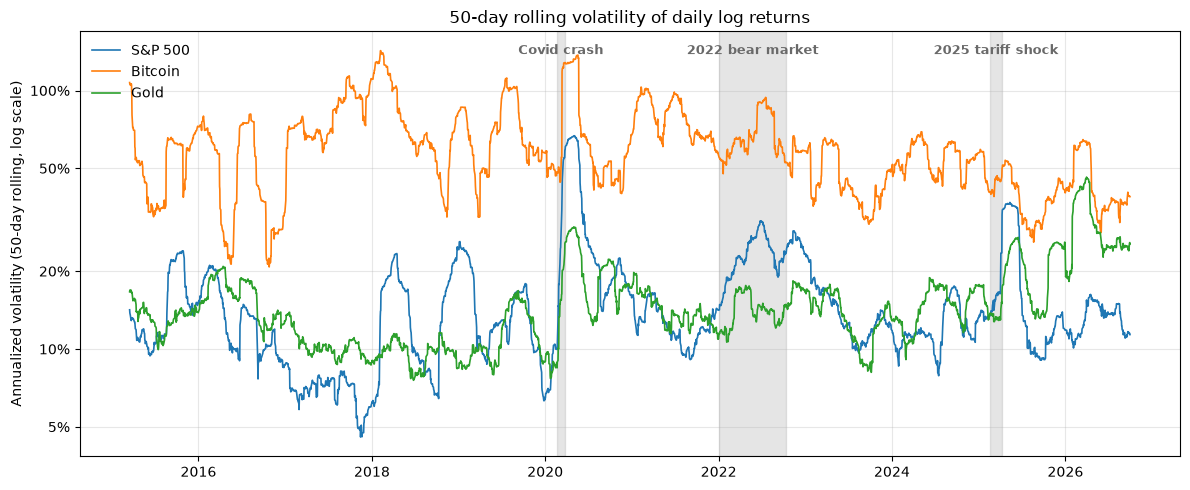

In [6]:
# --- run ---
vol_table = annualized_vol(returns["log"])
display(vol_table.style.format({"Annualized volatility": "{:.1%}",
                                "Ratio to S&P 500": "{:.2f}x"}))

vol_50d = rolling_vol(returns["log"])
fig, ax = plot_rolling_vol(vol_50d)
fig.savefig("assets/rolling_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

Bitcoin's volatility is about 3.8 times that of the S&P 500 over the full sample (66.0% vs 17.6%), while gold is slightly less volatile than equities on average (16.3%). Volatility is far from constant: it clusters, spikes simultaneously across assets in March 2020, and Bitcoin's level has trended down since 2020. The April 2025 tariff shock pushed S&P 500 volatility close to 40%, its highest level since 2020. The step-like drops are an artifact of the equal-weighted 50-day window: a shock stays in the estimate for exactly 50 days, then exits abruptly. The 2022 bear market shows that a large drawdown does not require extreme volatility.

## 3. Covariance and correlation

Four questions:

1. How correlated are Bitcoin and gold with equities over the full sample?
2. Do different closing times bias the daily correlation? On Yahoo Finance, Bitcoin closes at 00:00 UTC and US assets at 16:00 New York time. This is checked with lead-lag correlations, a Dimson (1979) correction and weekly (Friday-to-Friday) returns.
3. Did the correlations change in 2020? Fisher z-test for two independent correlations.
4. How do correlations evolve over time? 50- and 126-day rolling windows.

In [7]:
# --- parameters ---
PAIRS = [("Bitcoin", "S&P 500"), ("Gold", "S&P 500")]
CORR_WINDOWS = (50, 126)
SPLIT_DATE = "2020-01-01"


def corr_tables(log_returns, periods=TRADING_DAYS):
    """Full-sample correlation matrix and annualized covariance matrix."""
    return log_returns.corr(), log_returns.cov() * periods


def rolling_corr(log_returns, pairs=PAIRS, window=126):
    """Trailing rolling correlation for each pair of assets."""
    return pd.DataFrame({f"{a} / {b}": log_returns[a].rolling(window).corr(log_returns[b])
                         for a, b in pairs}).dropna()


def daily_vs_weekly_corr(log_returns, pairs=PAIRS):
    """Correlation on daily vs weekly (Friday-to-Friday) log returns.
    Weekly returns reduce the bias from non-synchronous closes
    (Bitcoin closes at 00:00 UTC on Yahoo, US assets at 16:00 New York time)."""
    weekly = log_returns.resample("W-FRI").sum()        # log returns are additive over time
    return pd.DataFrame({
        "Daily": [log_returns[a].corr(log_returns[b]) for a, b in pairs],
        "Weekly": [weekly[a].corr(weekly[b]) for a, b in pairs],
    }, index=[f"{a} / {b}" for a, b in pairs])


def corr_change_test(log_returns, a, b, split=SPLIT_DATE):
    """Fisher z-test: did the correlation between a and b change after `split`?
    Assumes independent observations (approximation with volatility clustering)."""
    before = log_returns[log_returns.index < split]
    after = log_returns[log_returns.index >= split]
    r1, r2 = before[a].corr(before[b]), after[a].corr(after[b])
    n1, n2 = len(before), len(after)
    z = (np.arctanh(r2) - np.arctanh(r1)) / np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    p = 2 * stats.norm.sf(abs(z))
    return pd.Series({"Corr before": r1, "Corr after": r2, "n before": n1,
                      "n after": n2, "z": z, "p-value": p}, name=f"{a} / {b}")


def plot_rolling_corr(log_returns, pairs=PAIRS, windows=CORR_WINDOWS, crises=CRISES):
    """One panel per pair, one line per window, crisis periods shaded."""
    fig, axes = plt.subplots(len(pairs), 1, figsize=(12, 3.5 * len(pairs)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (a, b) in zip(axes, pairs):
        for w in windows:
            rc = rolling_corr(log_returns, [(a, b)], window=w).iloc[:, 0]
            short = w == min(windows)
            ax.plot(rc.index, rc, label=f"{w}-day",
                    color="darkgrey" if short else "black", linewidth=1.0 if short else 1.6)
        ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
        shade_crises(ax, crises)
        ax.set_ylim(-1, 1)
        ax.set_ylabel("Correlation")
        ax.set_title(f"Rolling correlation of daily log returns: {a} vs {b}")
        ax.legend(loc="lower left", frameon=False)
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig, axes

def lead_lag_corr(log_returns, pairs=PAIRS, lags=(-1, 0, 1)):
    """Cross-correlation corr(a_t, b_{t+k}) at each lag k, plus a Dimson-corrected correlation.

    With non-synchronous closes (Bitcoin at 00:00 UTC, US assets at 16:00 New York),
    part of the co-movement shows up at lag +1: corr(BTC_t, SPY_{t+1}) > 0.
    Dimson (1979) sums the covariances at lags -1, 0, +1 to recover it.
    Under no correlation, each lag is ~ N(0, 1/n): the 95% band is +/- 1.96 / sqrt(n).
    """
    rows = {}
    for a, b in pairs:
        x, y = log_returns[a], log_returns[b]
        row = {f"lag {k:+d}": x.corr(y.shift(-k)) for k in lags}
        cov_sum = sum(x.cov(y.shift(-k)) for k in lags)
        row["Dimson-corrected"] = cov_sum / (x.std() * y.std())
        row["95% band (±)"] = 1.96 / np.sqrt(len(x))
        rows[f"{a} / {b}"] = row
    return pd.DataFrame(rows).T

,lag -1,lag +0,lag +1,Dimson-corrected,95% band (±)
Bitcoin / S&P 500,-0.0257,0.2441,-0.021,0.1975,0.0361
Gold / S&P 500,0.0228,0.0723,0.024,0.1190,0.0361


,S&P 500,Bitcoin,Gold
S&P 500,1.000,0.244,0.072
Bitcoin,0.244,1.000,0.104
Gold,0.072,0.104,1.000


,S&P 500,Bitcoin,Gold
S&P 500,0.0309,0.0283,0.0021
Bitcoin,0.0283,0.4359,0.0112
Gold,0.0021,0.0112,0.0266


,Daily,Weekly
Bitcoin / S&P 500,0.244,0.197
Gold / S&P 500,0.072,0.149


,Corr before,Corr after,n before,n after,z,p-value
Bitcoin / S&P 500,0.0232,0.3909,1257.0,1695.0,10.4561,0.0
Gold / S&P 500,-0.1676,0.1524,1257.0,1695.0,8.6640,0.0


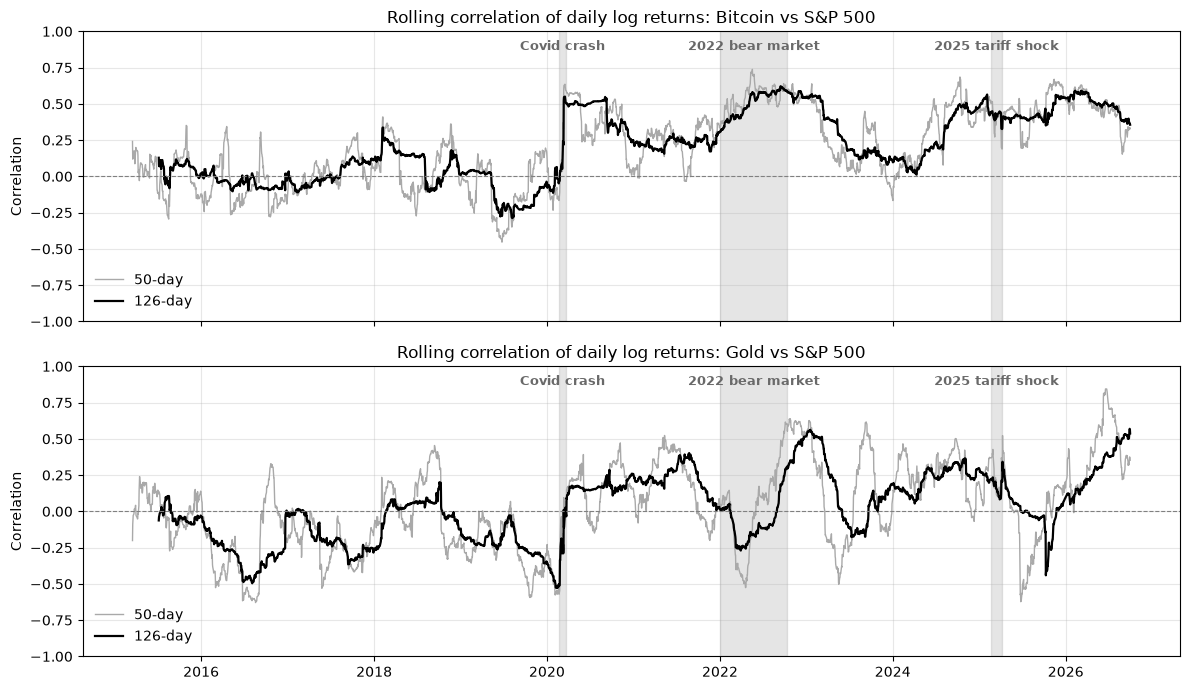

In [8]:
# --- run ---
display(lead_lag_corr(returns["log"]).round(4))

corr, cov_ann = corr_tables(returns["log"])

display(corr.round(3))

display(cov_ann.round(4))

display(daily_vs_weekly_corr(returns["log"]).round(3))


display(pd.DataFrame([corr_change_test(returns["log"], a, b) for a, b in PAIRS]).round(4))

fig, axes = plot_rolling_corr(returns["log"])
fig.savefig("assets/rolling_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

Over the full sample, Bitcoin's daily correlation with the S&P 500 is 0.24, and gold's is 0.07. A lead-lag analysis shows no significant cross-correlation at lags ±1, so the different closing times on Yahoo Finance do not bias the daily estimate. The Dimson-corrected and weekly correlations agree at about 0.20. The main finding is a regime change in 2020: Bitcoin's correlation with equities rose from 0.02 to 0.39, and gold's moved from −0.17 to +0.15 (Fisher z-tests, z = 10.5 and 8.7, both p < 0.001). The Fisher test assumes independent observations, so its p-value is optimistic under volatility clustering, but a z of 10 leaves no doubt. Rolling correlations confirm that these relationships are unstable and jump during market stress, partly because a few extreme days dominate the estimate.

## 4. Sharpe and Sortino ratios

Both ratios are computed on **excess simple returns** (asset return minus the daily risk-free rate) and annualized with √252.

- **Sharpe ratio:** mean excess return / standard deviation of excess returns.
- **Sortino ratio** (Sortino & Price, 1994): mean excess return / downside deviation, with the risk-free rate as the target and the downside deviation $\sqrt{\tfrac{1}{T}\sum_t \min(R_t - r_{f,t},\,0)^2}$ computed over **all** observations.

The risk-free rate (`DTB3`, % per year) is converted to a daily rate $(1+y)^{1/252}-1$, forward-filled over FRED holidays, aligned on trading days and lagged by one day (the rate known at the start of each holding period). The Sharpe ratio on log returns is also shown to measure the effect of the volatility drag.

In [9]:
def get_risk_free(index, series_id="DTB3", periods=TRADING_DAYS):
    """Daily risk-free rate aligned on `index`, from FRED (3-month T-bill, % per year).

    - converted to a daily rate: (1 + y)^(1/periods) - 1
    - forward-filled over FRED holidays, then aligned on the asset trading days
    - shifted by one day: the rate known at the START of each holding period
    """
    fred = Fred(api_key=os.getenv("FRED_API_KEY"))
    try:
        y = fred.get_series(series_id, observation_start=index[0] - pd.Timedelta(days=10),
                            observation_end=index[-1])
    except Exception as e:
        raise RuntimeError(f"FRED download failed for {series_id}: {e}") from e

    y = y.dropna() / 100                                   # % -> decimal
    rf = (1 + y) ** (1 / periods) - 1
    rf = rf.reindex(rf.index.union(index)).ffill().reindex(index)
    return rf.shift(1).bfill().rename("rf")


def performance_table(returns, rf, periods=TRADING_DAYS):
    """Annualized Sharpe and Sortino on excess SIMPLE returns, plus Sharpe on log returns.

    Sortino follows Sortino & Price (1994): target = risk-free rate,
    downside deviation = sqrt(mean(min(excess, 0)^2)) over ALL observations.
    """
    simple, log = returns["simple"], returns["log"]
    excess = simple.sub(rf, axis=0)
    excess_log = log.sub(np.log1p(rf), axis=0)

    downside_dev = np.sqrt((excess.clip(upper=0) ** 2).mean())

    table = pd.DataFrame({
        "CAGR": np.expm1(log.mean() * periods),
        "Volatility": simple.std() * np.sqrt(periods),
        "Sharpe": excess.mean() / excess.std() * np.sqrt(periods),
        "Sortino": excess.mean() / downside_dev * np.sqrt(periods),
        "Sharpe (log returns)": excess_log.mean() / excess_log.std() * np.sqrt(periods),
    })
    table["Rank Sharpe"] = table["Sharpe"].rank(ascending=False).astype(int)
    table["Rank Sortino"] = table["Sortino"].rank(ascending=False).astype(int)
    return table

In [10]:
# --- run ---
rf = get_risk_free(returns.index)
print(f"Risk-free rate: mean {rf.mean() * TRADING_DAYS:.2%} per year, "
      f"{rf.isna().sum()} missing values")

perf = performance_table(returns, rf)
display(perf.style.format({"CAGR": "{:.1%}", "Volatility": "{:.1%}", "Sharpe": "{:.2f}",
                           "Sortino": "{:.2f}", "Sharpe (log returns)": "{:.2f}"}))

Risk-free rate: mean 2.05% per year, 0 missing values


,CAGR,Volatility,Sharpe,Sortino,Sharpe (log returns),Rank Sharpe,Rank Sortino
S&P 500,13.7%,17.5%,0.70,0.99,0.61,2,2
Bitcoin,61.0%,65.7%,1.02,1.54,0.69,1,1
Gold,10.8%,16.3%,0.59,0.83,0.51,3,3


Using SPY instead of the S&P 500 price index adds about 1.8 percentage points of annual return from reinvested dividends. On excess simple returns, Bitcoin ranks first by both Sharpe (1.02) and Sortino (1.54), ahead of the S&P 500 (0.70 and 0.99) and gold (0.59 and 0.83): focusing on downside risk does not change the ranking. The Sortino-to-Sharpe ratio is informative, though: about 1.41 for the S&P 500 and gold, below the roughly 1.46 expected under normality, versus 1.51 for Bitcoin. On simple returns, Bitcoin's distribution is symmetric (skewness 0.02), while the S&P 500 (−0.30) and gold (−0.46) are negatively skewed, which is exactly the ordering of the Sortino-to-Sharpe ratios. On log returns, the volatility drag (about σ²/2) cuts Bitcoin's Sharpe by 0.33 and the S&P 500's by only 0.09, shrinking Bitcoin's lead from 0.32 to 0.08.

## 5. Normality

The Sharpe ratio and its usual standard error assume normal returns. This section measures how far each asset is from that assumption: skewness, excess kurtosis (0 for a normal distribution), Jarque-Bera and D'Agostino-Pearson tests, the number of days beyond ±3σ compared with the 0.27% expected under normality, and the rarity of each asset's worst day under a normal law.

In [11]:
# --- parameters ---
SIGMA_THRESHOLD = 3


def normality_table(log_returns):
    """Shape of each distribution and two normality tests.
    pandas .kurt() returns EXCESS kurtosis: 0 for a normal distribution."""
    rows = {}
    for col in log_returns:
        x = log_returns[col]
        jb = stats.jarque_bera(x)
        dp = stats.normaltest(x)                       # D'Agostino-Pearson
        rows[col] = {"Skewness": x.skew(), "Excess kurtosis": x.kurt(),
                     "Jarque-Bera": jb.statistic, "JB p-value": jb.pvalue,
                     "D'Agostino": dp.statistic, "DA p-value": dp.pvalue}
    return pd.DataFrame(rows).T


def tail_count_table(log_returns, k=SIGMA_THRESHOLD):
    """Days beyond +/- k standard deviations: observed vs expected under normality.
    One-sided binomial test (more extreme days than expected).
    Assumes independent days: optimistic under volatility clustering."""
    p_normal = 2 * stats.norm.sf(k)                    # 0.27% for k = 3
    rows = {}
    for col in log_returns:
        x = log_returns[col]
        z = (x - x.mean()) / x.std()
        n, observed = len(x), int((z.abs() > k).sum())
        rows[col] = {"Days": n, "Observed": observed, "Expected": n * p_normal,
                     "Ratio": observed / (n * p_normal),
                     "Binomial p-value": stats.binomtest(observed, n, p_normal,
                                                         alternative="greater").pvalue}
    return pd.DataFrame(rows).T


def worst_day_table(log_returns, periods=TRADING_DAYS):
    """Worst day of each asset, its z-score, and how rare it would be under a normal law."""
    rows = {}
    for col in log_returns:
        x = log_returns[col]
        date = x.idxmin()
        z = (x.min() - x.mean()) / x.std()
        p = stats.norm.cdf(z)
        rows[col] = {"Date": date.date(), "Log return": x.min(),
                     "Simple return": np.expm1(x.min()), "z-score": z,
                     "Normal probability": p, "Once every ... years": 1 / (p * periods)}
    return pd.DataFrame(rows).T

In [12]:
# --- run ---
log_r = returns["log"]

display(normality_table(log_r).style.format(
    {"Skewness": "{:.2f}", "Excess kurtosis": "{:.1f}", "Jarque-Bera": "{:,.0f}",
     "JB p-value": "{:.1e}", "D'Agostino": "{:,.0f}", "DA p-value": "{:.1e}"}))

display(pd.DataFrame({"Skewness (log)": returns["log"].skew(),
                      "Skewness (simple)": returns["simple"].skew()}).round(2))

display(tail_count_table(log_r).style.format(
    {"Days": "{:,.0f}", "Observed": "{:.0f}", "Expected": "{:.1f}",
     "Ratio": "{:.1f}x", "Binomial p-value": "{:.1e}"}))

display(worst_day_table(log_r).style.format(
    {"Log return": "{:.2%}", "Simple return": "{:.2%}", "z-score": "{:.1f}",
     "Normal probability": "{:.1e}", "Once every ... years": "{:.1e}"}))

,Skewness,Excess kurtosis,Jarque-Bera,JB p-value,D'Agostino,DA p-value
S&P 500,-0.57,14.5,"26,037",0.0e+00,777,1.7e-169
Bitcoin,-0.61,9.8,"11,962",0.0e+00,678,6.6e-148
Gold,-0.60,7.3,"6,689",0.0e+00,584,1.2e-127


,Skewness (log),Skewness (simple)
S&P 500,-0.57,-0.30
Bitcoin,-0.61,0.02
Gold,-0.60,-0.46


,Days,Observed,Expected,Ratio,Binomial p-value
S&P 500,"2,952",40,8.0,5.0x,5.1e-16
Bitcoin,"2,952",51,8.0,6.4x,1.8e-24
Gold,"2,952",44,8.0,5.5x,5.9e-19


,Date,Log return,Simple return,z-score,Normal probability,Once every ... years
S&P 500,2020-03-16,-11.59%,-10.94%,-10.5,3.6e-26,1.1e+23
Bitcoin,2020-03-12,-46.47%,-37.17%,-11.2,1.6e-29,2.4e+26
Gold,2026-01-30,-10.84%,-10.27%,-10.6,1.7e-26,2.4e+23


All three assets are far from normal. On log returns, skewness is negative and similar across assets (about −0.6), and excess kurtosis ranges from 7 (gold) to 14.5 (S&P 500). Skewness depends heavily on the return definition: on simple returns it rises to 0.02 for Bitcoin, −0.30 for the S&P 500 and −0.46 for gold. The log transform stretches losses more for high-volatility assets, and a handful of extreme days dominate this third-moment statistic. With about 2,950 observations, the normality tests reject at p < 10⁻¹⁰⁰: the size of the deviation, not the p-value, is the informative part. Each asset has 5 to 6.4 times more days beyond ±3σ than a normal distribution predicts. Counter-intuitively, the S&P 500 has the fattest tails relative to its own volatility: it alternates calm regimes and crises, and this mixture creates extreme kurtosis. Each asset's worst day lies 10.5 to 11 standard deviations below its mean (S&P 500 on 16 March 2020, Bitcoin on 12 March 2020, gold on 30 January 2026). Under a normal law, such a day would occur once every 10²³ to 10²⁶ years, about 10¹³ times the age of the universe, yet each 12-year sample contains one.

## 6. Student t distribution

A Student t distribution is fitted to each asset's log returns by maximum likelihood. Its degrees of freedom ν measure tail thickness: the variance exists only for ν > 2, the skewness for ν > 3 and the kurtosis for ν > 4. The fit is compared with the normal distribution by AIC, by QQ-plots, and by the probability each law assigns to the worst day.

In [13]:
def fit_student(log_returns, periods=TRADING_DAYS):
    """Fit a Student t by maximum likelihood (MLE) to each asset and compare it with a normal.

    - nu: degrees of freedom (lower = fatter tails; nu <= 4 -> infinite theoretical kurtosis)
    - AIC = 2k - 2 log-likelihood (k = 2 for the normal, 3 for the Student): lower is better
    - worst day probability under both laws, as a frequency in years
    """
    rows = {}
    for col in log_returns:
        x = log_returns[col]
        nu, loc, scale = stats.t.fit(x)
        mu, sigma = x.mean(), x.std()

        ll_t = stats.t.logpdf(x, nu, loc, scale).sum()
        ll_n = stats.norm.logpdf(x, mu, sigma).sum()

        p_t = stats.t.cdf(x.min(), nu, loc, scale)
        p_n = stats.norm.cdf(x.min(), mu, sigma)

        rows[col] = {
            "nu": nu, "loc": loc, "scale": scale,
            "Implied std (Student)": scale * np.sqrt(nu / (nu - 2)) if nu > 2 else np.inf,
            "Sample std": sigma,
            "Theoretical excess kurtosis": 6 / (nu - 4) if nu > 4 else np.inf,
            "Sample excess kurtosis": x.kurt(),
            "AIC normal - AIC Student": (2 * 2 - 2 * ll_n) - (2 * 3 - 2 * ll_t),
            "Worst day: once every ... years (normal)": 1 / (p_n * periods),
            "Worst day: once every ... years (Student)": 1 / (p_t * periods),
        }
    return pd.DataFrame(rows).T


def plot_qq(log_returns, fits):
    """QQ-plots of each asset against the fitted normal and the fitted Student t.
    Points on the 45-degree line = the law reproduces the observed quantiles."""
    cols = list(log_returns.columns)
    fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 5))
    for ax, col in zip(np.atleast_1d(axes), cols):
        x = np.sort(log_returns[col].values)
        p = (np.arange(1, len(x) + 1) - 0.5) / len(x)       # plotting positions
        nu, loc, scale = fits.loc[col, ["nu", "loc", "scale"]].astype(float)

        q_norm = stats.norm.ppf(p, x.mean(), x.std(ddof=1))
        q_t = stats.t.ppf(p, nu, loc, scale)

        ax.scatter(q_norm, x, s=6, color="grey", alpha=0.6, label="Normal")
        ax.scatter(q_t, x, s=6, color="black", alpha=0.8, label=f"Student t (ν = {nu:.1f})")
        lim = [min(x.min(), q_t.min()), max(x.max(), q_t.max())]
        ax.plot(lim, lim, color="red", linewidth=1, linestyle="--")
        ax.set_title(col)
        ax.set_xlabel("Theoretical quantile (daily log return)")
        ax.set_ylabel("Observed quantile")
        ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
        ax.legend(loc="upper left", frameon=False)
        ax.grid(True, alpha=0.3)
    fig.suptitle("QQ-plots: fitted normal vs fitted Student t")
    fig.tight_layout()
    return fig, axes

,nu,loc,scale,Implied std (Student),Sample std,Theoretical excess kurtosis,Sample excess kurtosis,AIC normal - AIC Student,Worst day: once every ... years (normal),Worst day: once every ... years (Student)
S&P 500,2.76,0.00092,0.0064,0.0122,0.0111,inf,14.5,936,1.1e+23,13
Bitcoin,2.30,0.00170,0.0224,0.0622,0.0416,inf,9.8,882,2.4e+26,7
Gold,3.73,0.00057,0.0072,0.0105,0.0103,inf,7.3,454,2.4e+23,47


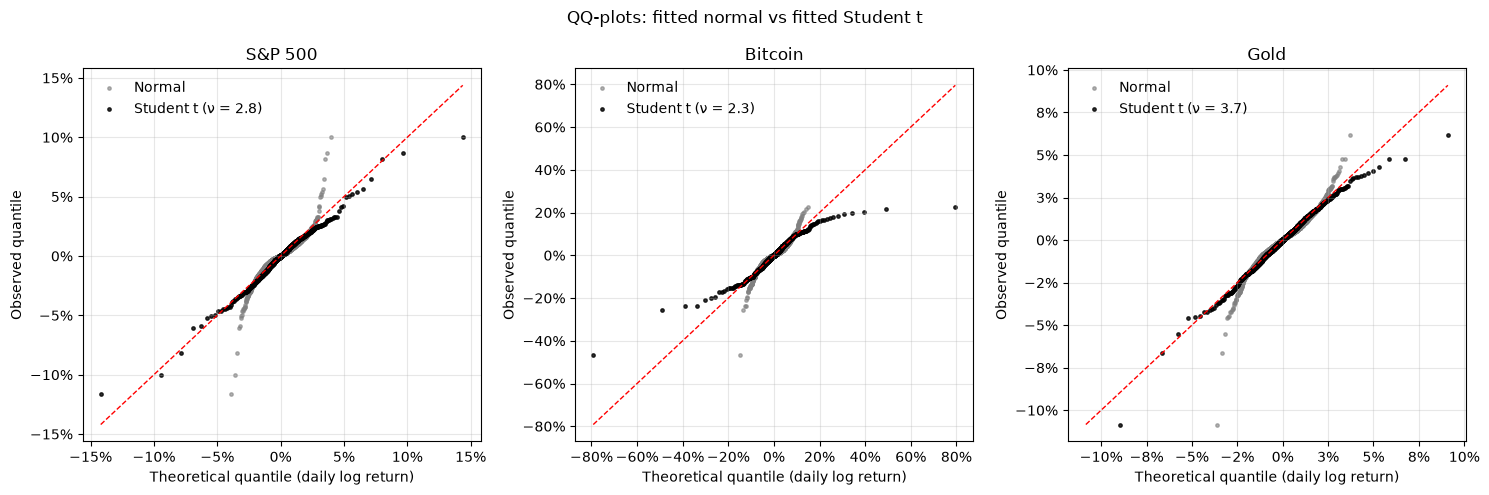

In [14]:
# --- run ---
fits = fit_student(returns["log"])
display(fits.style.format({
    "nu": "{:.2f}", "loc": "{:.5f}", "scale": "{:.4f}",
    "Implied std (Student)": "{:.4f}", "Sample std": "{:.4f}",
    "Theoretical excess kurtosis": "{:.1f}", "Sample excess kurtosis": "{:.1f}",
    "AIC normal - AIC Student": "{:,.0f}",
    "Worst day: once every ... years (normal)": "{:.1e}",
    "Worst day: once every ... years (Student)": "{:,.0f}"}))

fig, axes = plot_qq(returns["log"], fits)
fig.savefig("assets/qq_plots.png", dpi=150, bbox_inches="tight")
plt.show()

A Student t fitted by maximum likelihood describes all three assets far better than a normal distribution (AIC improvements of 450 to 940). The fitted degrees of freedom are very low: 2.8 for the S&P 500, 2.3 for Bitcoin and 3.7 for gold. With ν < 4, theoretical kurtosis is infinite, and with ν < 3 (S&P 500, Bitcoin) even skewness is undefined, so the sample kurtosis and skewness reported above are unstable estimates. Under the Student, each worst day becomes a plausible event, expected once every 7 to 47 years instead of once every 10²³ years. The fit is not perfect, though: for Bitcoin, the implied standard deviation is 50% above the sample one, and the QQ-plot shows that the Student predicts more extreme days than observed. The normal law has tails that are too thin, the unconditional Student tails that are too fat. A single distribution fitted on the whole sample mixes calm and turbulent regimes; modelling time-varying volatility (e.g. GARCH with Student innovations) is the natural next step.

## 7. Confidence intervals for Sharpe ratios

A Sharpe ratio estimated over 12 years is itself uncertain. Its standard error is computed on the daily Sharpe ratio $SR$ over $T$ days, then scaled by √252:

- Lo (2002), i.i.d. normal returns: $\operatorname{Var}(\widehat{SR}) \approx \dfrac{1 + SR^2/2}{T}$
- Mertens (2002), i.i.d. non-normal returns: $\operatorname{Var}(\widehat{SR}) \approx \dfrac{1 + SR^2/2 - \gamma_3\,SR + \tfrac{\gamma_4 - 3}{4}\,SR^2}{T}$

where $\gamma_3$ is the skewness and $\gamma_4 - 3$ the excess kurtosis of excess returns.

In [15]:
CONFIDENCE = 0.95


def sharpe_ci_mertens(returns, rf, periods=TRADING_DAYS, confidence=CONFIDENCE):
    """Annualized Sharpe ratio with Lo (2002) and Mertens (2002) standard errors.

    Daily SR = mean(excess) / std(excess), on excess SIMPLE returns (as in step 4).
    Lo, i.i.d. normal:      Var(SR) = (1 + SR^2 / 2) / T
    Mertens, i.i.d. non-normal:
        Var(SR) = (1 + SR^2 / 2 - skew * SR + (excess kurtosis / 4) * SR^2) / T
    (pandas .kurt() already returns EXCESS kurtosis: do not subtract 3 again.)
    SR and its standard error are both scaled by sqrt(periods).
    """
    excess = returns["simple"].sub(rf, axis=0)
    z = stats.norm.ppf(0.5 + confidence / 2)
    rows = {}
    for col in excess:
        x = excess[col]
        T = len(x)
        sr = x.mean() / x.std()
        g3, g4_excess = x.skew(), x.kurt()

        se_lo = np.sqrt((1 + sr**2 / 2) / T)
        se_mertens = np.sqrt((1 + sr**2 / 2 - g3 * sr + g4_excess / 4 * sr**2) / T)

        scale = np.sqrt(periods)
        rows[col] = {"Sharpe": sr * scale,
                     "SE (Lo, normal)": se_lo * scale,
                     "SE (Mertens)": se_mertens * scale,
                     "CI low": (sr - z * se_mertens) * scale,
                     "CI high": (sr + z * se_mertens) * scale,
                     "t-stat (SR > 0)": sr / se_mertens}
    return pd.DataFrame(rows).T


def plot_sharpe_ci(table, confidence=CONFIDENCE):
    """Annualized Sharpe ratios with their Mertens confidence intervals."""
    t = table.sort_values("Sharpe")
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.errorbar(t["Sharpe"], t.index,
                xerr=[t["Sharpe"] - t["CI low"], t["CI high"] - t["Sharpe"]],
                fmt="o", color="black", ecolor="grey", elinewidth=2, capsize=5)
    ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel(f"Annualized Sharpe ratio ({confidence:.0%} CI, Mertens standard error)")
    ax.set_title("Sharpe ratios and their uncertainty")
    ax.grid(True, axis="x", alpha=0.3)
    fig.tight_layout()
    return fig, ax

,Sharpe,"SE (Lo, normal)",SE (Mertens),CI low,CI high,t-stat (SR > 0)
S&P 500,0.70,0.29,0.30,0.13,1.28,2.38
Bitcoin,1.02,0.29,0.29,0.45,1.60,3.49
Gold,0.59,0.29,0.30,0.01,1.17,1.99


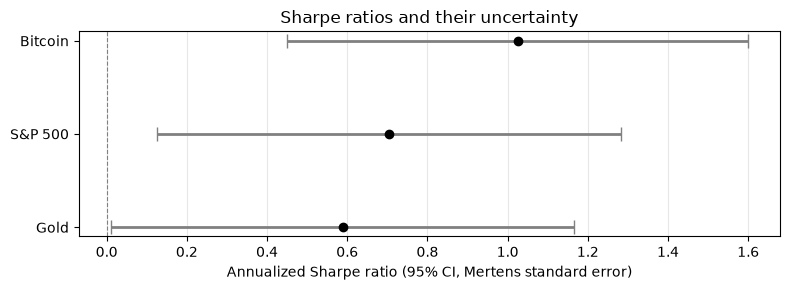

In [16]:
# --- run ---
sharpe_ci = sharpe_ci_mertens(returns, rf)
display(sharpe_ci.style.format("{:.2f}"))

fig, ax = plot_sharpe_ci(sharpe_ci)
fig.savefig("assets/sharpe_ci.png", dpi=150, bbox_inches="tight")
plt.show()

Mertens (2002) standard errors are about 0.29–0.30 for all three assets, almost identical to Lo's normal-i.i.d. formula: with a daily Sharpe ratio near 0.05, the skewness and kurtosis corrections are multiplied by tiny numbers. The uncertainty comes from the length of the sample (about 1/√years), not from fat tails. All three Sharpe ratios are positive at the 5% level, gold only barely (t = 1.99), but the 95% intervals are wide: Bitcoin's spans 0.45 to 1.60, and all three intervals overlap. As a rough guide, if the gap between Bitcoin and the S&P 500 stayed at 0.32 with a return correlation of 0.24, about 57 years of daily data would be needed to make it significant at the 5% level. Overlapping intervals are not a formal test, however: the next section tests the difference directly.

## 8. Testing the Sharpe ratio difference

Null hypothesis: Bitcoin and the S&P 500 have the same Sharpe ratio. Two approaches:

- **Analytic test:** Jobson & Korkie (1981) with Memmel's (2003) correction, which accounts for the correlation between the two assets but assumes i.i.d. normal returns.
- **Paired circular block bootstrap** (10,000 draws, blocks of 5, 20 and 50 days, fixed seed). Blocks of consecutive days preserve volatility clustering; drawing the *same* days for both assets preserves their correlation. The p-value is the share of draws whose distance from the observed difference is at least as large as the observed difference itself.

In [17]:
# --- parameters ---
BLOCK_LENGTHS = (5, 20, 50)
N_BOOT = 10_000
SEED = 42


def circular_block_indices(T, block, n_boot, rng):
    """Index matrix (n_boot x T) for a circular block bootstrap.
    Blocks of consecutive days keep volatility clustering; wrapping around
    the end of the sample gives every day the same chance of being drawn."""
    n_blocks = int(np.ceil(T / block))
    starts = rng.integers(0, T, size=(n_boot, n_blocks))
    idx = (starts[:, :, None] + np.arange(block)) % T
    return idx.reshape(n_boot, -1)[:, :T]


def bootstrap_sharpe_diff(excess, a, b, block, n_boot=N_BOOT, seed=SEED,
                          periods=TRADING_DAYS, chunk=1_000):
    """Paired circular block bootstrap of Sharpe(a) - Sharpe(b), annualized.
    PAIRED: the same days are drawn for both assets, so their correlation is preserved."""
    rng = np.random.default_rng(seed)
    X = excess[[a, b]].to_numpy()
    T = len(X)
    diffs = []
    for start in range(0, n_boot, chunk):
        idx = circular_block_indices(T, block, min(chunk, n_boot - start), rng)
        sample = X[idx]                                   # (chunk, T, 2)
        sr = sample.mean(axis=1) / sample.std(axis=1, ddof=1) * np.sqrt(periods)
        diffs.append(sr[:, 0] - sr[:, 1])
    return np.concatenate(diffs)


def memmel_se(excess, a, b, periods=TRADING_DAYS):
    """Analytic SE of Sharpe(a) - Sharpe(b) under i.i.d. normal returns
    (Jobson-Korkie test with Memmel's 2003 correction), annualized."""
    x, y = excess[a], excess[b]
    T = len(x)
    s1, s2, rho = x.mean() / x.std(), y.mean() / y.std(), x.corr(y)
    var = (2 * (1 - rho) + 0.5 * (s1**2 + s2**2 - 2 * s1 * s2 * rho**2)) / T
    return np.sqrt(var * periods)


def sharpe_diff_test(returns, rf, pairs=PAIRS, blocks=BLOCK_LENGTHS, periods=TRADING_DAYS):
    """Observed Sharpe difference, analytic test, and block bootstrap for each block length."""
    excess = returns["simple"].sub(rf, axis=0)
    sr = excess.mean() / excess.std() * np.sqrt(periods)
    rows, draws = [], {}
    for a, b in pairs:
        d_obs = sr[a] - sr[b]
        se_an = memmel_se(excess, a, b, periods)
        rows.append({"Pair": f"{a} - {b}", "Method": "Analytic (Memmel, i.i.d. normal)",
                     "Difference": d_obs, "SE": se_an,
                     "CI low": d_obs - 1.96 * se_an, "CI high": d_obs + 1.96 * se_an,
                     "p-value": 2 * stats.norm.sf(abs(d_obs) / se_an)})
        for block in blocks:
            d = bootstrap_sharpe_diff(excess, a, b, block)
            draws[(a, b, block)] = d
            rows.append({"Pair": f"{a} - {b}", "Method": f"Block bootstrap ({block} days)",
                         "Difference": d_obs, "SE": d.std(ddof=1),
                         "CI low": np.percentile(d, 2.5), "CI high": np.percentile(d, 97.5),
                         # centered bootstrap test of H0: difference = 0
                         "p-value": np.mean(np.abs(d - d_obs) >= abs(d_obs))})
    return pd.DataFrame(rows).set_index(["Pair", "Method"]), draws


def plot_bootstrap(draws, a, b, block):
    """Bootstrap distribution of the Sharpe difference, with 0 and the 95% interval."""
    d = draws[(a, b, block)]
    lo, hi = np.percentile(d, [2.5, 97.5])
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(d, bins=80, color="grey", alpha=0.7)
    ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="No difference")
    ax.axvline(np.mean(d), color="black", linewidth=1.5, label="Bootstrap mean")
    ax.axvspan(lo, hi, color="grey", alpha=0.15, label="95% interval")
    ax.set_xlabel(f"Sharpe({a}) - Sharpe({b}), annualized")
    ax.set_ylabel("Bootstrap draws")
    ax.set_title(f"Paired block bootstrap ({block}-day blocks, {len(d):,} draws)")
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig, ax

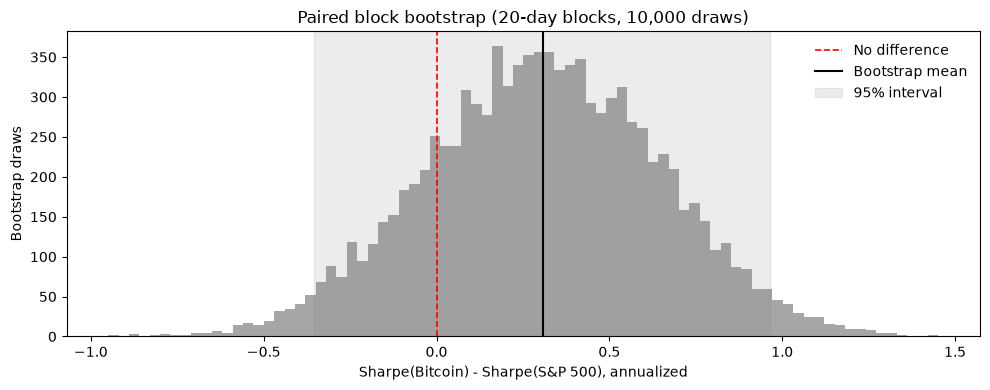

In [18]:
# --- run ---
diff_table, boot_draws = sharpe_diff_test(returns, rf)
display(diff_table.style.format("{:.3f}"))

fig, ax = plot_bootstrap(boot_draws, "Bitcoin", "S&P 500", block=20)
fig.savefig("assets/sharpe_diff_bootstrap.png", dpi=150, bbox_inches="tight")
plt.show()

Bitcoin's Sharpe ratio exceeds the S&P 500's by 0.32, but this difference is not statistically significant. The analytic Jobson-Korkie test with Memmel's correction and the paired circular block bootstrap agree: standard errors of 0.33 to 0.36, p-values of 0.33 to 0.38, and 95% intervals that all contain zero (−0.35 to 0.97 with 20-day blocks). The data are consistent with Bitcoin being clearly better, equivalent, or slightly worse than the S&P 500 on a risk-adjusted basis. The conclusion is robust to the block length: longer blocks slightly reduce the standard error, because the precision of a Sharpe ratio depends mainly on the autocorrelation of returns, which is slightly negative, rather than on volatility clustering. Gold and the S&P 500 are also statistically indistinguishable (difference −0.12, p ≈ 0.76).

## 9. Stability over time

The key statistics are re-estimated on three sub-samples:

- **2015–2019 vs 2020 onwards**, before and after the correlation regime change found in section 3;
- **from January 2018**, just after Bitcoin's December 2017 peak, to test the sensitivity to the start date (January 2015 follows Bitcoin's 2014 crash).

A 2-year rolling Sharpe ratio shows the instability continuously.

In [19]:
# --- parameters ---
SUBPERIODS = {
    "Full sample": (None, None),
    "2015-2019": (None, "2019-12-31"),
    "2020 onwards": ("2020-01-01", None),
    "From 2018 (after the 2017 Bitcoin peak)": ("2018-01-01", None),
}
ROLLING_SHARPE_WINDOW = 504          # 2 years of trading days


def stability_tables(returns, rf, subperiods=SUBPERIODS, benchmark="S&P 500",
                     test_pair=("Bitcoin", "S&P 500"), block=20, periods=TRADING_DAYS):
    """Re-run the key statistics on each sub-period.
    Table 1: volatility, Sharpe, Student nu and correlation with the benchmark, per asset.
    Table 2: Sharpe difference test (analytic Memmel + paired block bootstrap)."""
    asset_rows, test_rows = [], []
    a, b = test_pair
    for name, (start, end) in subperiods.items():
        r, rf_p = returns.loc[start:end], rf.loc[start:end]
        excess = r["simple"].sub(rf_p, axis=0)
        log_r = r["log"]
        sr = excess.mean() / excess.std() * np.sqrt(periods)

        for col in log_r:
            asset_rows.append({
                "Period": name, "Asset": col,
                "Start": log_r.index[0].date(), "End": log_r.index[-1].date(),
                "Volatility": log_r[col].std() * np.sqrt(periods),
                "Sharpe": sr[col],
                "Student nu": stats.t.fit(log_r[col])[0],
                f"Corr with {benchmark}": log_r[col].corr(log_r[benchmark]),
            })

        d_obs = sr[a] - sr[b]
        se_an = memmel_se(excess, a, b, periods)
        d = bootstrap_sharpe_diff(excess, a, b, block)
        test_rows.append({
            "Period": name, "Years": len(excess) / periods,
            f"Sharpe {a}": sr[a], f"Sharpe {b}": sr[b], "Difference": d_obs,
            "SE (Memmel)": se_an, "p-value (Memmel)": 2 * stats.norm.sf(abs(d_obs) / se_an),
            f"CI low (bootstrap {block}d)": np.percentile(d, 2.5),
            f"CI high (bootstrap {block}d)": np.percentile(d, 97.5),
            f"p-value (bootstrap {block}d)": np.mean(np.abs(d - d_obs) >= abs(d_obs)),
        })
    return (pd.DataFrame(asset_rows).set_index(["Period", "Asset"]),
            pd.DataFrame(test_rows).set_index("Period"))


def plot_rolling_sharpe(returns, rf, window=ROLLING_SHARPE_WINDOW,
                        periods=TRADING_DAYS, crises=CRISES):
    """Trailing rolling Sharpe ratio of each asset (window in trading days)."""
    excess = returns["simple"].sub(rf, axis=0)
    roll = (excess.rolling(window).mean() / excess.rolling(window).std()
            * np.sqrt(periods)).dropna()
    fig, ax = plt.subplots(figsize=(12, 5))
    for col in roll:
        ax.plot(roll.index, roll[col], label=col, linewidth=1.3)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    shade_crises(ax, crises)
    ax.set_ylabel(f"Annualized Sharpe ratio ({window // periods}-year rolling)")
    ax.set_title(f"{window // periods}-year rolling Sharpe ratio (excess simple returns)")
    ax.legend(loc="upper left", frameon=False)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig, ax

,Years,Sharpe Bitcoin,Sharpe S&P 500,Difference,SE (Memmel),p-value (Memmel),CI low (bootstrap 20d),CI high (bootstrap 20d),p-value (bootstrap 20d)
Period,,,,,,,,,
Full sample,11.71,1.02,0.70,0.32,0.36,0.38,-0.35,0.96,0.35
2015-2019,4.99,1.21,0.81,0.40,0.63,0.52,-0.73,1.46,0.47
2020 onwards,6.73,0.87,0.67,0.20,0.43,0.65,-0.62,0.95,0.62
From 2018 (after the 2017 Bitcoin peak),8.72,0.59,0.67,-0.08,0.40,0.85,-0.84,0.64,0.84


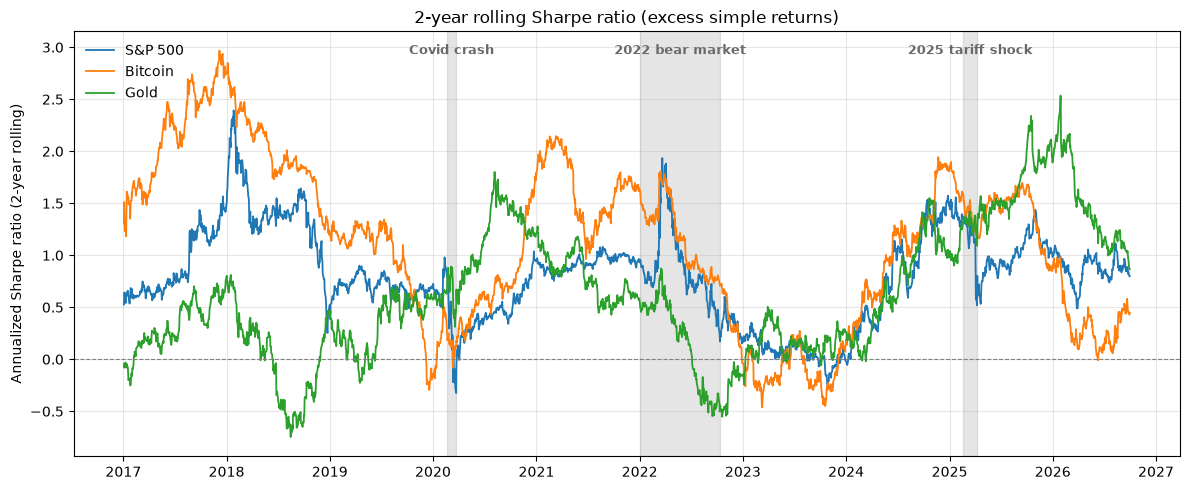

In [20]:
# --- run ---
asset_stab, test_stab = stability_tables(returns, rf)
display(asset_stab.style.format({"Volatility": "{:.1%}", "Sharpe": "{:.2f}",
                                 "Student nu": "{:.2f}", "Corr with S&P 500": "{:.2f}"}))
display(test_stab.style.format("{:.2f}"))

fig, ax = plot_rolling_sharpe(returns, rf)
fig.savefig("assets/rolling_sharpe.png", dpi=150, bbox_inches="tight")
plt.show()

The ranking is not robust to the choice of period. Starting in January 2018 instead of January 2015 cuts Bitcoin's Sharpe ratio from 1.02 to 0.59 and moves it from first to last, behind the S&P 500 (0.67) and gold (0.69). The difference with the S&P 500 is not significant in any sub-period (p-values of 0.47 to 0.84), as the shorter samples widen the standard errors to 0.40–0.63. Since 2020, Bitcoin's volatility has fallen (from 73% to 61%) while equity and gold volatility rose, and its correlation with equities has jumped. The fitted Student degrees of freedom for Bitcoin drop below 2 in 2015–2019, which implies infinite variance and makes that sub-period's Sharpe ratio ill-defined in this model. The 2-year rolling Sharpe ratio shows each asset taking the lead at some point, with Bitcoin ranging from −0.4 to 3.0, although overlapping windows mean these reversals are not independent observations.

## 10. Conclusion

Bitcoin appears to beat the S&P 500 on a risk-adjusted basis, but with 12 years of data this advantage cannot be distinguished from chance. Its Sharpe ratio lead (1.02 vs 0.70) has a p-value of about 0.35, disappears when the sample starts in 2018, and the same gap would need about 57 years of daily data to become significant. Fat tails are real and large, but they barely affect the precision of a daily Sharpe ratio: the binding constraint is the number of years. Two results hold firmly, however: none of the three return distributions is normal, and the correlation of both Bitcoin and gold with equities rose in 2020, which weakens their diversification benefits over this period. The practical lesson is to report the uncertainty of any Sharpe ratio comparison, and to check that a ranking survives a change of start date before drawing conclusions from it.

## Limitations

- **Independence assumptions.** The binomial test, the Fisher test, the Mertens and Memmel standard errors and √252 annualization all assume i.i.d. returns; volatility clustering makes them somewhat optimistic. The block bootstrap addresses this partly.
- **Simplified bootstrap.** The percentile block bootstrap is a simplified version of the studentized bootstrap of Ledoit & Wolf (2008).
- **Calendar alignment.** Returns are computed on US trading days, so Bitcoin's Monday return covers three calendar days. Yahoo Finance closes Bitcoin at 00:00 UTC and US assets at 16:00 New York time; no significant lead-lag effect was found.
- **ETF fees.** SPY (about 0.09% per year) and GLD (about 0.40%) fees are already deducted from prices: the returns are those an investor actually earned.
- **Risk-free rate.** `DTB3` is quoted on a discount basis; the difference with an investment yield is negligible here.
- **Unconditional distributions.** The Student t is fitted on the whole sample with constant volatility; time-varying volatility (GARCH) is not modelled.
- **Data and period.** A single data source (Yahoo Finance) and a single 12-year window; section 9 shows that results depend on the period.

## References

- D'Agostino, R. & Pearson, E. S. (1973). Tests for departure from normality. *Biometrika*, 60(3), 613–622.
- Dimson, E. (1979). Risk measurement when shares are subject to infrequent trading. *Journal of Financial Economics*, 7(2), 197–226.
- Fisher, R. A. (1915). Frequency distribution of the values of the correlation coefficient in samples from an indefinitely large population. *Biometrika*, 10(4), 507–521.
- Jarque, C. M. & Bera, A. K. (1987). A test for normality of observations and regression residuals. *International Statistical Review*, 55(2), 163–172.
- Jobson, J. D. & Korkie, B. M. (1981). Performance hypothesis testing with the Sharpe and Treynor measures. *Journal of Finance*, 36(4), 889–908.
- Ledoit, O. & Wolf, M. (2008). Robust performance hypothesis testing with the Sharpe ratio. *Journal of Empirical Finance*, 15(5), 850–859.
- Lo, A. W. (2002). The statistics of Sharpe ratios. *Financial Analysts Journal*, 58(4), 36–52.
- Memmel, C. (2003). Performance hypothesis testing with the Sharpe ratio. *Finance Letters*, 1, 21–23.
- Mertens, E. (2002). Comments on variance of the IID estimator in Lo (2002). Working paper, University of Basel.
- Politis, D. N. & Romano, J. P. (1992). A circular block-resampling procedure for stationary data. In R. LePage & L. Billard (eds.), *Exploring the Limits of Bootstrap*, Wiley, 263–270.
- Sortino, F. A. & Price, L. N. (1994). Performance measurement in a downside risk framework. *Journal of Investing*, 3(3), 59–64.

---

**Didier Matton** | Financial Engineer | Full-Stack Data Scientist | Python, Django, VBA, BI & LLMs | Quantitative Finance